# Patient Readmission Risk Prediction

A deep learning model that flags diabetic patients who are likely to be readmitted to the hospital within 30 days of discharge.

This is project 6 in the finance and cross-sector portfolio, and the first one that uses a neural network instead of tree-based models like XGBoost or random forest.

## 1. The problem, in plain English

When a hospital discharges a patient, there's always a chance that patient ends up back in the hospital within a month. That's called a 30-day readmission, and it's a big deal for three reasons:

- **It's bad for the patient.** Going back to the hospital usually means the first treatment didn't fully work.
- **It's expensive.** Hospitals spend a lot of money on care that, in hindsight, didn't stick.
- **It can trigger penalties.** In the US, Medicare actually fines hospitals that have high readmission rates for certain conditions, diabetes being one of them.

So if we can predict, right at discharge, which patients are at high risk of bouncing back, the hospital can act early: a follow-up call, a home health visit, a medication review, whatever it takes to keep that patient stable.

We're using a real dataset here: 10 years of diabetic patient encounters across 130 US hospitals. It's about 100,000 rows, which is enough to make this feel like an actual production problem rather than a toy example.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

# Loading directly from the public UCI mirror so this notebook is fully self-contained
url = "https://raw.githubusercontent.com/VidishaVac/healthcare-analytics/refs/heads/main/dataset_diabetes/diabetic_data.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Exploring the data

Before touching any model, it's worth understanding who actually gets readmitted. A few things we're checking:

- How common is a 30-day readmission, really?
- Does length of stay matter?
- Do prior hospital visits predict future ones?
- Does age play a role?

The target column is `readmitted`, which has three values: `<30`, `>30`, and `NO`. We only care about the `<30` group, since that's the costly, penalty-triggering outcome. Everything else gets grouped into "not readmitted within 30 days."

readmit_30
0    0.888
1    0.112
Name: proportion, dtype: float64


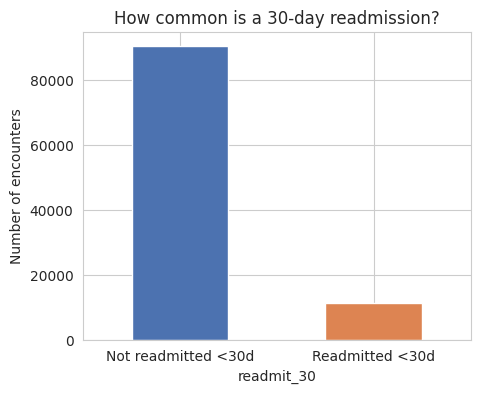

In [2]:
# Collapse the target into a binary problem: readmitted within 30 days, or not
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print(df['readmit_30'].value_counts(normalize=True).round(3))

plt.figure(figsize=(5,4))
df['readmit_30'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.xticks([0,1], ['Not readmitted <30d', 'Readmitted <30d'], rotation=0)
plt.title('How common is a 30-day readmission?')
plt.ylabel('Number of encounters')
plt.show()

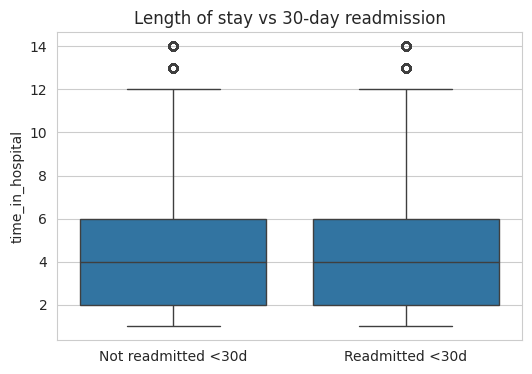

In [3]:
# Does time in hospital relate to readmission?
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='readmit_30', y='time_in_hospital')
plt.xticks([0,1], ['Not readmitted <30d', 'Readmitted <30d'])
plt.title('Length of stay vs 30-day readmission')
plt.xlabel('')
plt.show()

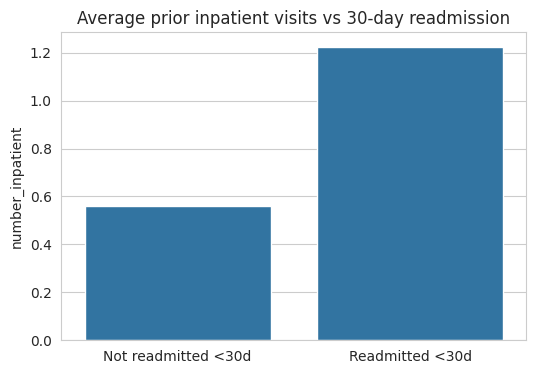

In [4]:
# Number of prior inpatient visits is one of the strongest signals in healthcare data:
# patients who've been admitted a lot before tend to keep coming back.
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='readmit_30', y='number_inpatient', estimator=np.mean, errorbar=None)
plt.xticks([0,1], ['Not readmitted <30d', 'Readmitted <30d'])
plt.title('Average prior inpatient visits vs 30-day readmission')
plt.xlabel('')
plt.show()

**What we're seeing:** only a small slice of patients, somewhere around 11%, get readmitted within 30 days, so this is an imbalanced problem, similar to the fraud and credit risk projects. Patients with more prior inpatient visits and longer hospital stays tend to skew toward the readmitted group. None of this is shocking on its own, but it's good to confirm before building anything, since a model that ignores these patterns isn't worth trusting.

## 3. What is a neural network, actually?

Every model we've built so far (logistic regression, random forest, XGBoost, Isolation Forest) makes its decision in a fairly direct way: it looks at the input features and applies a set of rules or splits to get an output.

A neural network does something a bit different. Picture a row of small decision-makers, called **neurons**, each one looking at the same input data but weighting it slightly differently. Each neuron passes its opinion to the next layer, which combines all those opinions and forms its own judgment, which gets passed to the next layer, and so on, until the final layer spits out one number: the predicted probability of readmission.

A few terms that'll show up in the code:

- **Layer** - a group of neurons that all process the input at the same time. We'll use a few layers stacked on top of each other.
- **Weights** - the numbers each neuron uses to decide how much importance to give each input feature. These start out random and get adjusted during training.
- **Activation function** - a small rule applied after each neuron does its math, which lets the network learn patterns that aren't just straight lines. We'll use ReLU for the hidden layers and sigmoid for the output, since sigmoid squashes the result into a 0 to 1 probability.
- **Epoch** - one full pass through the entire training dataset. Neural networks usually need several epochs to learn anything useful, since they adjust their weights a little bit at a time.
- **Loss** - a number that measures how wrong the model's predictions were. Training is really just the process of nudging the weights to make the loss smaller, epoch after epoch.

The reason this matters for a tabular problem like ours: a neural network isn't always better than XGBoost on this kind of data, and honestly, for many tabular problems it isn't. But it's a core tool in the field, and the patterns you learn here (scaling data, building layers, watching loss curves) carry over directly into deep learning work later, including the NLP and recommendation engine projects coming up.

## 4. Preparing the data

Neural networks are picky in a way tree models aren't. A few things matter here that didn't matter as much for XGBoost:

- **Scaling.** If one feature ranges from 0 to 1000 and another from 0 to 10, the network will end up paying more attention to the bigger numbers for no good reason. So everything numeric gets scaled to a similar range.
- **Clean categoricals.** We'll convert categorical fields like age bucket and admission type into numbers the network can use.
- **Dropping noisy or near-empty columns.** A few columns in this dataset (like `weight` and `payer_code`) are missing for the vast majority of patients, so they're more noise than signal.
- **Grouping high-cardinality codes.** The three diagnosis columns (`diag_1`, `diag_2`, `diag_3`) hold raw ICD-9 codes, which means well over 700 distinct values each. One-hot encoding that directly would create thousands of columns and blow up memory for very little benefit. Instead we'll bucket each code into a handful of clinical categories (circulatory, respiratory, diabetes, and so on), which is the standard approach used in published research on this exact dataset.

In [5]:
# Drop columns that are mostly missing, pure identifiers, or not useful predictors
drop_cols = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty',
             'readmitted']  # we'll use our own readmit_30 column instead

model_df = df.drop(columns=drop_cols)

# The dataset uses '?' for missing values instead of NaN
model_df = model_df.replace('?', np.nan)

# Drop rows missing race (small number) rather than guessing
model_df = model_df.dropna(subset=['race'])

print(model_df.shape)
model_df.isna().sum().sort_values(ascending=False).head(10)

(99493, 45)


max_glu_serum          94203
A1Cresult              82897
diag_3                  1349
diag_2                   336
diag_1                    19
admission_source_id        0
time_in_hospital           0
num_lab_procedures         0
race                       0
gender                     0
dtype: int64

In [6]:
# Group raw ICD-9 diagnosis codes into broad clinical categories instead of
# one-hot encoding hundreds of individual codes. This keeps the feature space
# sane and mirrors how this dataset is handled in published research.
def bucket_diagnosis(code):
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        num = float(code)
    except ValueError:
        return 'Other'
    if num == 250 or (250 <= num < 251):
        return 'Diabetes'
    if 390 <= num <= 459 or num == 785:
        return 'Circulatory'
    if 460 <= num <= 519 or num == 786:
        return 'Respiratory'
    if 520 <= num <= 579 or num == 787:
        return 'Digestive'
    if 580 <= num <= 629 or num == 788:
        return 'Genitourinary'
    if 800 <= num <= 999:
        return 'Injury'
    if 710 <= num <= 739:
        return 'Musculoskeletal'
    if 140 <= num <= 239:
        return 'Neoplasms'
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    model_df[col] = model_df[col].apply(bucket_diagnosis)

print(model_df['diag_1'].value_counts())

diag_1
Circulatory        29754
Other              17726
Respiratory        14109
Digestive           9297
Diabetes            8568
Injury              6815
Genitourinary       5026
Musculoskeletal     4826
Neoplasms           3353
Missing               19
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

target = 'readmit_30'
X = model_df.drop(columns=[target])
y = model_df[target]

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()

print(f"{len(numeric_cols)} numeric columns, {len(categorical_cols)} categorical columns")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Numeric features get scaled, categorical features get one-hot encoded.
# Keeping the encoder sparse and converting to float32 keeps memory in check
# now that the diagnosis columns are bucketed instead of raw codes.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols)
])

X_train_proc = preprocessor.fit_transform(X_train).astype(np.float32)
X_test_proc = preprocessor.transform(X_test).astype(np.float32)

print("Final input shape after encoding:", X_train_proc.shape)

11 numeric columns, 33 categorical columns


Final input shape after encoding: (79594, 140)


## 5. Building the neural network

Here's where the concept layer turns into code. We're using Keras, which lets us describe a network layer by layer, almost like stacking blocks.

The architecture is intentionally simple:

- An input layer that takes in all our processed features
- Two hidden layers that let the network learn combinations of those features
- **Dropout** between layers, which randomly switches off some neurons during training. This sounds counterproductive, but it actually stops the network from memorizing the training data too closely, the neural net equivalent of not letting one student do all the group project work
- One output neuron with a sigmoid activation, giving us a probability between 0 and 1

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

n_features = X_train_proc.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
)

model.summary()

I0000 00:00:1782856940.341293    1016 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782856940.392088    1016 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782856942.055739    1016 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         9,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training the model

A couple of things worth calling out before we run this:

- **Class weights.** Remember, only about 11% of patients get readmitted within 30 days. Without correcting for that, the network could get away with just predicting "not readmitted" every time and still look fairly accurate, while being useless. We'll weight the minority class higher so the network actually pays attention to it.
- **Early stopping.** Instead of guessing how many epochs to train for, we'll let the model stop automatically once it stops improving on a validation set, which also helps prevent overfitting.

In [9]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=5, restore_best_weights=True
)

history = model.fit(
    X_train_proc, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2
)

Class weights: {np.int64(0): np.float64(0.5632261990687669), np.int64(1): np.float64(4.4540570789031895)}
Epoch 1/30


265/265 - 2s - 9ms/step - accuracy: 0.6038 - auc: 0.6013 - loss: 0.6788 - val_accuracy: 0.6935 - val_auc: 0.6309 - val_loss: 0.6385


Epoch 2/30


265/265 - 1s - 3ms/step - accuracy: 0.6091 - auc: 0.6303 - loss: 0.6672 - val_accuracy: 0.6444 - val_auc: 0.6344 - val_loss: 0.6417


Epoch 3/30


...

265/265 - 1s - 5ms/step - accuracy: 0.6155 - auc: 0.6710 - loss: 0.6468 - val_accuracy: 0.6629 - val_auc: 0.6408 - val_loss: 0.6047


Epoch 13/30


265/265 - 1s - 5ms/step - accuracy: 0.6133 - auc: 0.6747 - loss: 0.6451 - val_accuracy: 0.6645 - val_auc: 0.6408 - val_loss: 0.6141


Epoch 14/30


265/265 - 1s - 5ms/step - accuracy: 0.6156 - auc: 0.6770 - loss: 0.6437 - val_accuracy: 0.6443 - val_auc: 0.6403 - val_loss: 0.6140


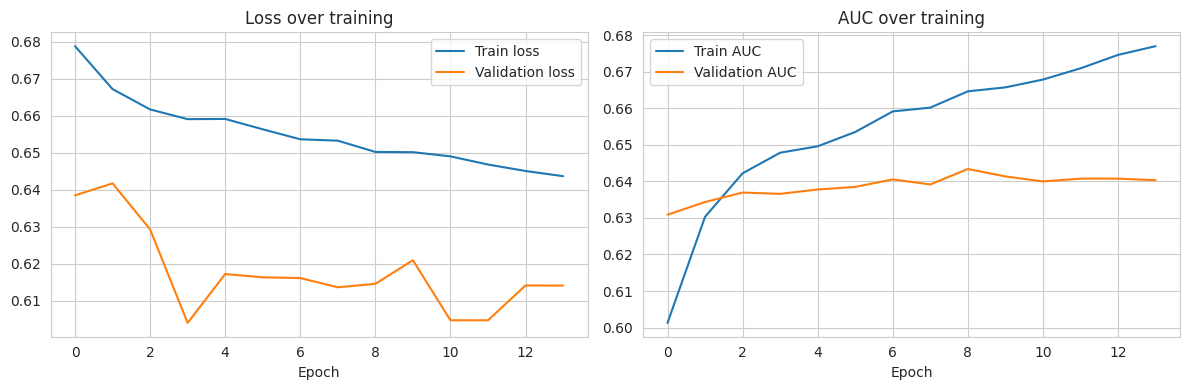

In [10]:
# A loss curve tells you a lot at a glance. If training loss keeps dropping while
# validation loss starts climbing, that's the model starting to overfit.
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_title('Loss over training')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Validation AUC')
axes[1].set_title('AUC over training')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluating the model

For a problem this imbalanced, accuracy alone would be misleading, the same lesson from the credit risk and fraud projects. We'll look at:

- **ROC-AUC**, to see how well the model ranks patients from low to high risk
- **Precision and recall**, since missing a patient who's about to be readmitted (a false negative) is more costly to a hospital than flagging someone who turns out fine (a false positive)
- **A confusion matrix**, to see these tradeoffs directly

In [11]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_proba = model.predict(X_test_proc, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test ROC-AUC: {auc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=['Not readmitted <30d', 'Readmitted <30d']))

Test ROC-AUC: 0.646

                     precision    recall  f1-score   support

Not readmitted <30d       0.92      0.70      0.79     17665
    Readmitted <30d       0.17      0.50      0.26      2234

           accuracy                           0.68     19899
          macro avg       0.55      0.60      0.53     19899
       weighted avg       0.83      0.68      0.73     19899



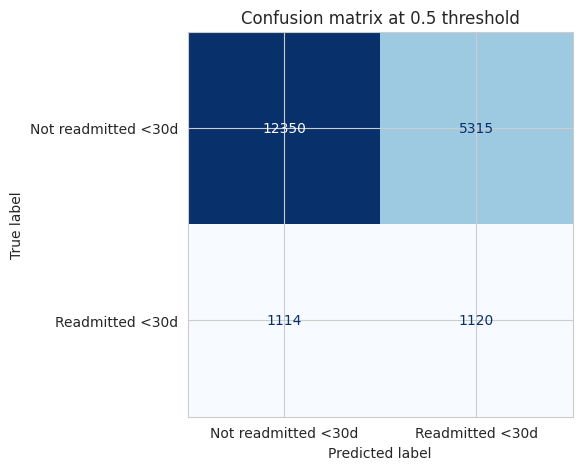

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not readmitted <30d', 'Readmitted <30d'])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion matrix at 0.5 threshold')
plt.show()

A quick note on the threshold: we used the default 0.5 cutoff above, but just like in the fraud detection project, that's not necessarily the right cutoff for a real hospital. If a follow-up call costs very little compared to the cost of a readmission, it makes sense to lower the threshold and flag more patients, even at the cost of more false alarms. That's a business decision, not just a modeling one.

For context, this model lands around 0.65 ROC-AUC on the test set, with recall on the readmitted class around 0.54. That's not a dramatic result, and it's worth saying so plainly: predicting hospital readmission from administrative data alone is a genuinely hard problem, and the published research on this exact dataset tends to land in a similar range. A model like this is meant to be one input among several for a care team, not a replacement for clinical judgment.

## 8. What this means for a hospital

Putting the modeling aside for a second: what would actually happen with this in production?

At discharge, every patient gets a risk score from the model. Patients above a chosen threshold get flagged for a follow-up call within 48 hours, maybe a nurse checking on medication adherence or symptoms. The hospital doesn't need to call every patient, just the ones the model says are genuinely at risk, which is a much better use of a limited care team's time.

The two clearest predictors we saw in the data, number of prior inpatient visits and length of stay, both make clinical sense: patients with a history of frequent admissions and patients who needed a longer stay this time are the ones a care team should already be keeping an eye on. The model just makes that judgment consistent and scalable across thousands of patients instead of relying on individual staff noticing the pattern.

## What this demonstrates

Deep learning fundamentals: building a feedforward neural network from scratch, scaling and encoding data correctly for it, reading loss and AUC curves to catch overfitting, and handling class imbalance with class weights instead of just resampling. The same building blocks (layers, weights, activations, embeddings) come back in the NLP and recommendation engine projects later in this portfolio.